# Ender20 hybrid stability analysis

## tl;dr

Frozen-gate result: **`NOT_PROMOTION_ELIGIBLE`**. Calibration selection: **`none`**.
The analysis uses 5,112,039 out-of-fold rows across 855 consecutive eras and
does not retrain or upload a model.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

RESULT_JSON = Path('results/hybrid_stability_result.json')
SUMMARY_CSV = Path('results/hybrid_stability_summary.csv')
PER_ERA_CSV = Path('results/hybrid_stability_per_era.csv')

result = json.loads(RESULT_JSON.read_text(encoding="utf-8"))
summary = pd.read_csv(SUMMARY_CSV)
per_era = pd.read_csv(PER_ERA_CSV, dtype={"era": str})

assert result["cohort"]["rows"] == 5_112_039
assert result["cohort"]["eras"] == 855
assert len(per_era["era"].unique()) == 855
print(result["state"], "| selected:", result["selected_candidate"])


NOT_PROMOTION_ELIGIBLE | selected: None


## Context & Methods

The prior TabM residual retained positive unique Ender20 signal but failed its
production gate because full-period BMC maximum drawdown was about 0.301. This
experiment combines that fixed residual with Numerai's official
`v53_lgbm_ender20` benchmark. Both inputs are percentile-ranked within era,
combined at five weights frozen before scoring, and percentile-ranked again.

The first 655 chronological OOF eras are calibration. The final 200 eras are a
locked holdout. Candidate selection uses calibration only; the holdout can
accept or reject that one selection but cannot substitute another weight.

### Key Assumptions

- The OOF parquet's prediction-semantics metadata correctly identifies a raw
  benchmark-residual model output.
- Manifest IDs, eras, targets, and official benchmark predictions are the exact
  generation used by the earlier validated feature store.
- Per-era Corr, BMC, benchmark similarity, Sharpe, and additive maximum drawdown
  are suitable offline diagnostics, not guarantees of live performance.
- Thresholds and blend weights in `gate.md` were frozen before any hybrid result
  was computed.


## Data

In [2]:
provenance = pd.DataFrame([
    {
        "input": name,
        "path": details["path"],
        "sha256": details["sha256"],
    }
    for name, details in result["inputs"].items()
    if isinstance(details, dict) and "sha256" in details
])
display(pd.Series(result["cohort"], name="cohort"))
display(provenance)


calibration_eras         655
eras                     855
first_era               0371
first_holdout_era       1026
holdout_eras             200
last_era                1225
rows                 5112039
Name: cohort, dtype: object

,input,path,sha256
0,gate,numerai/agents/experiments/ender20_hybrid_stab...,f284b2b9e71ab824787715a6c42a33f2bd7f06b37ee14a...
1,manifest,numerai/v5.3/target_ender_20_feature_store/man...,07eded145ab7249bfe3fa17cd109a343a9ac5cd9502750...
2,predictions,numerai/agents/experiments/ender20_nn_architec...,196f56053eb23a04d32c80118dd90e99c41290c99cefcf...


## Results

In [3]:
columns = [
    "segment", "candidate", "bmc_mean", "bmc_sharpe",
    "bmc_max_drawdown", "corr_mean", "avg_corr_with_benchmark",
]
candidate_table = summary.loc[
    summary["candidate"].str.startswith("hybrid_"), columns
].copy()
display(candidate_table.round(6).reset_index(drop=True))


,segment,candidate,bmc_mean,bmc_sharpe,bmc_max_drawdown,corr_mean,avg_corr_with_benchmark
0,calibration,hybrid_w35,0.002658,0.442194,0.143763,0.037317,0.896565
1,calibration,hybrid_w45,0.003594,0.481929,0.174572,0.035052,0.799838
2,calibration,hybrid_w55,0.004494,0.507279,0.206746,0.032200,0.663896
3,calibration,hybrid_w65,0.005277,0.527577,0.234389,0.028776,0.516544
4,calibration,hybrid_w75,0.005866,0.541986,0.255389,0.024875,0.379329
5,holdout,hybrid_w35,0.001838,0.334145,0.058743,0.022286,0.879299
6,holdout,hybrid_w45,0.002375,0.360256,0.062213,0.020405,0.755080
7,holdout,hybrid_w55,0.002868,0.375247,0.062933,0.017979,0.573738
8,holdout,hybrid_w65,0.003261,0.389497,0.061925,0.015040,0.384887
9,holdout,hybrid_w75,0.003560,0.402585,0.064379,0.012024,0.220628


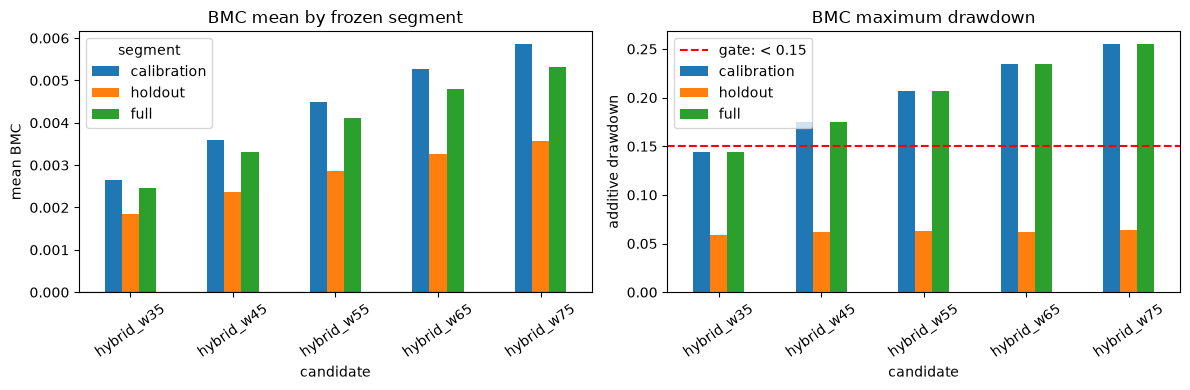

In [4]:
plot_data = candidate_table.pivot(
    index="candidate", columns="segment", values=["bmc_mean", "bmc_max_drawdown"]
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_data["bmc_mean"][["calibration", "holdout", "full"]].plot.bar(
    ax=axes[0], title="BMC mean by frozen segment"
)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_ylabel("mean BMC")
plot_data["bmc_max_drawdown"][["calibration", "holdout", "full"]].plot.bar(
    ax=axes[1], title="BMC maximum drawdown"
)
axes[1].axhline(0.15, color="red", linestyle="--", label="gate: < 0.15")
axes[1].set_ylabel("additive drawdown")
axes[1].legend()
for axis in axes:
    axis.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()


In [5]:
calibration = pd.DataFrame(result["calibration_candidates"]).T
calibration["failed_checks"] = calibration["checks"].map(
    lambda checks: ", ".join(name for name, passed in checks.items() if not passed) or "none"
)
display(calibration[["eligible", "failed_checks"]])

promotion = pd.Series(result["promotion_checks"], name="passed")
display(promotion.to_frame())
print("Final state:", result["state"])


,eligible,failed_checks
hybrid_w35,False,bmc_sharpe
hybrid_w45,False,"benchmark_corr_retention, bmc_max_drawdown"
hybrid_w55,False,"benchmark_corr_retention, bmc_max_drawdown"
hybrid_w65,False,"benchmark_corr_retention, bmc_max_drawdown"
hybrid_w75,False,"benchmark_corr_retention, bmc_max_drawdown"


,passed


Final state: NOT_PROMOTION_ELIGIBLE


## Takeaways

No frozen weight cleared calibration eligibility, so the experiment stops without inspecting holdout weights for a replacement winner.

The final 200 eras are formula-new but not fully data-new: prior research already
reported aggregate recent performance for the residual reference. These results
are therefore a robustness check, not a substitute for live validation. Offline
metrics also cannot prove Numerai-hosted Docker compatibility or future returns.
